## **Poverty Prediction Challenge**

In [110]:
#1. Initially, when I trained the models after removing outliers, the accuracy was very high. But when I removed the outliers, the accuracy decreased.
#2. Even after performing data scaling, the model's accuracy remains the same.
#3. Feature Selection (I ran the feature selection code for 30 minutes, but the process didn't complete, so I stopped it.)
#4. Feature Extraction
#5. Cross Validation
#6. Hyper paramter Tuning
#7. Scaling [StandardScaler, RobustScaler(outlier effected)]

In [111]:
import pandas as pd
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
pd.set_option('display.max_columns', None)


#preprocessing
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.cross_decomposition import PLSRegression

#model
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor


#metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [112]:
x_train = pd.read_csv("C:\\Users\\USER\\OneDrive\\Desktop\\AI\\Kaggle Hackthon\\3. Poverty Prediction Challenge\\Data\\train_hh_features.csv")
y_train = pd.read_csv("C:\\Users\\USER\\OneDrive\\Desktop\\AI\\Kaggle Hackthon\\3. Poverty Prediction Challenge\\Data\\train_hh_gt.csv")

x_final_test = pd.read_csv("C:\\Users\\USER\\OneDrive\\Desktop\\AI\\Kaggle Hackthon\\3. Poverty Prediction Challenge\\Data\\Test data\\test_hh_features.csv")

In [113]:
print("X Train Shape:", x_train.shape)
x_train.head()

X Train Shape: (104234, 88)


,hhid,com,weight,strata,utl_exp_ppp17,male,hsize,num_children5,num_children10,num_children18,age,owner,water,toilet,sewer,elect,water_source,sanitation_source,dweltyp,num_adult_female,num_adult_male,num_elderly,employed,sworkershh,share_secondary,educ_max,sfworkershh,any_nonagric,sector1d,region1,region2,region3,region4,region5,region6,region7,urban,consumed100,consumed200,consumed300,consumed400,consumed500,consumed600,consumed700,consumed800,consumed900,consumed1000,consumed1100,consumed1200,consumed1300,consumed1400,consumed1500,consumed1600,consumed1700,consumed1800,consumed1900,consumed2000,consumed2100,consumed2200,consumed2300,consumed2400,consumed2500,consumed2600,consumed2700,consumed2800,consumed2900,consumed3000,consumed3100,consumed3200,consumed3300,consumed3400,consumed3500,consumed3600,consumed3700,consumed3800,consumed3900,consumed4000,consumed4100,consumed4200,consumed4300,consumed4400,consumed4500,consumed4600,consumed4700,consumed4800,consumed4900,consumed5000,survey_id
0,100001,1,75,4,594.80627,Female,1,0,0,0,75,Owner,Access,Access,Access,Access,Piped water into dwelling,A piped sewer system,Detached house,0,0,1,Not employed,0.000000,0.000000,Incomplete Secondary Education,0.0,No,NaN,0,1,0,0,0,0,0,Urban,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Yes,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,No,100000
1,100002,1,150,4,1676.27230,Female,2,0,0,0,61,Owner,Access,Access,Access,Access,Piped water into dwelling,A piped sewer system,Detached house,1,0,1,Not employed,0.000000,0.000000,Complete Tertiary Education,0.0,No,NaN,0,1,0,0,0,0,0,Urban,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,No,Yes,Yes,No,No,100000
2,100003,1,375,4,506.93719,Male,5,0,0,2,49,Owner,Access,Access,Access,Access,Piped water into dwelling,A piped sewer system,Detached house,1,2,0,Employed,0.666667,0.333333,Incomplete Tertiary Education,0.5,Yes,"Transport, storage and communications",0,1,0,0,0,0,0,Urban,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,Yes,No,No,Yes,Yes,Yes,No,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes,100000
3,100004,1,375,4,824.61786,Male,5,0,0,1,58,Not owner,Access,Access,Access,No access,Piped water into dwelling,A piped sewer system,Detached house,1,3,0,Employed,1.250000,0.250000,Incomplete Tertiary Education,0.2,Yes,Public administration and defence,0,1,0,0,0,0,0,Urban,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,Yes,Yes,Yes,No,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,No,No,Yes,No,No,No,Yes,Yes,No,No,100000
4,100005,1,525,4,351.47644,Male,7,1,0,0,57,Owner,Access,Access,Access,Access,Piped water into dwelling,A piped sewer system,Detached house,2,3,1,Employed,0.666667,0.333333,Complete Tertiary Education,0.5,Yes,Construction,0,1,0,0,0,0,0,Urban,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,Yes,Yes,No,No,Yes,Yes,Yes,No,Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,No,Yes,Yes,Yes,No,100000


In [114]:
print("Y Train shape:", y_train.shape)
y_train.head()

Y Train shape: (104234, 3)


,survey_id,hhid,cons_ppp17
0,100000,100001,25.258402
1,100000,100002,16.996706
2,100000,100003,13.671848
3,100000,100004,7.189475
4,100000,100005,12.308855


In [115]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104234 entries, 0 to 104233
Data columns (total 88 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   hhid               104234 non-null  int64  
 1   com                104234 non-null  int64  
 2   weight             104234 non-null  int64  
 3   strata             104234 non-null  int64  
 4   utl_exp_ppp17      104149 non-null  float64
 5   male               104234 non-null  object 
 6   hsize              104234 non-null  int64  
 7   num_children5      104234 non-null  int64  
 8   num_children10     104234 non-null  int64  
 9   num_children18     104234 non-null  int64  
 10  age                104234 non-null  int64  
 11  owner              104234 non-null  object 
 12  water              104234 non-null  object 
 13  toilet             104234 non-null  object 
 14  sewer              104234 non-null  object 
 15  elect              104234 non-null  object 
 16  wa

In [116]:
x_train.columns

Index(['hhid', 'com', 'weight', 'strata', 'utl_exp_ppp17', 'male', 'hsize',
       'num_children5', 'num_children10', 'num_children18', 'age', 'owner',
       'water', 'toilet', 'sewer', 'elect', 'water_source',
       'sanitation_source', 'dweltyp', 'num_adult_female', 'num_adult_male',
       'num_elderly', 'employed', 'sworkershh', 'share_secondary', 'educ_max',
       'sfworkershh', 'any_nonagric', 'sector1d', 'region1', 'region2',
       'region3', 'region4', 'region5', 'region6', 'region7', 'urban',
       'consumed100', 'consumed200', 'consumed300', 'consumed400',
       'consumed500', 'consumed600', 'consumed700', 'consumed800',
       'consumed900', 'consumed1000', 'consumed1100', 'consumed1200',
       'consumed1300', 'consumed1400', 'consumed1500', 'consumed1600',
       'consumed1700', 'consumed1800', 'consumed1900', 'consumed2000',
       'consumed2100', 'consumed2200', 'consumed2300', 'consumed2400',
       'consumed2500', 'consumed2600', 'consumed2700', 'consumed2800',
 

## Preprocessing data

#### 1. Missing value handle

In [117]:
x_train['utl_exp_ppp17'].isnull().sum()

85

In [118]:
## Missing Vaules Analysis
pd.set_option('display.max_rows', None)
x_train.isnull().sum()

hhid                     0
com                      0
weight                   0
strata                   0
utl_exp_ppp17           85
male                     0
hsize                    0
num_children5            0
num_children10           0
num_children18           0
age                      0
owner                    0
water                    0
toilet                   0
sewer                    0
elect                    0
water_source             0
sanitation_source        0
dweltyp               1206
num_adult_female         0
num_adult_male           0
num_elderly              0
employed                45
sworkershh               0
share_secondary         23
educ_max                23
sfworkershh              0
any_nonagric             0
sector1d             14129
region1                  0
region2                  0
region3                  0
region4                  0
region5                  0
region6                  0
region7                  0
urban                    0
c

In [119]:
# Identify missing value columns 
null_cols = []
for col in x_train.columns:
    if x_train[col].isnull().sum() > 0:
        null_cols.append(col)
x_train[null_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104234 entries, 0 to 104233
Data columns (total 56 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   utl_exp_ppp17    104149 non-null  float64
 1   dweltyp          103028 non-null  object 
 2   employed         104189 non-null  object 
 3   share_secondary  104211 non-null  float64
 4   educ_max         104211 non-null  object 
 5   sector1d         90105 non-null   object 
 6   consumed100      104232 non-null  object 
 7   consumed200      104232 non-null  object 
 8   consumed300      104232 non-null  object 
 9   consumed400      104232 non-null  object 
 10  consumed500      104232 non-null  object 
 11  consumed600      104233 non-null  object 
 12  consumed700      104232 non-null  object 
 13  consumed800      104233 non-null  object 
 14  consumed900      104233 non-null  object 
 15  consumed1000     104230 non-null  object 
 16  consumed1100     104230 non-null  obje

#Missing Value filling

In [120]:
# int/object data type columns filling with mode

for col in null_cols:
    x_train[col].fillna(x_train[col].mode()[0], inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_14228\2343591765.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  x_train[col].fillna(x_train[col].mode()[0], inplace=True)


In [121]:
x_train.isnull().sum().sum()

0

#Check Duplicated Data 

In [122]:
x_train.duplicated().sum()

0

#Drop column

In [123]:
x_train['com'].unique()

array([1], dtype=int64)

In [124]:
x_train.drop(columns=['hhid', 'com', 'survey_id'], inplace=True)

### 2. Data Encoding

In [125]:
x_train.head(3)

,weight,strata,utl_exp_ppp17,male,hsize,num_children5,num_children10,num_children18,age,owner,water,toilet,sewer,elect,water_source,sanitation_source,dweltyp,num_adult_female,num_adult_male,num_elderly,employed,sworkershh,share_secondary,educ_max,sfworkershh,any_nonagric,sector1d,region1,region2,region3,region4,region5,region6,region7,urban,consumed100,consumed200,consumed300,consumed400,consumed500,consumed600,consumed700,consumed800,consumed900,consumed1000,consumed1100,consumed1200,consumed1300,consumed1400,consumed1500,consumed1600,consumed1700,consumed1800,consumed1900,consumed2000,consumed2100,consumed2200,consumed2300,consumed2400,consumed2500,consumed2600,consumed2700,consumed2800,consumed2900,consumed3000,consumed3100,consumed3200,consumed3300,consumed3400,consumed3500,consumed3600,consumed3700,consumed3800,consumed3900,consumed4000,consumed4100,consumed4200,consumed4300,consumed4400,consumed4500,consumed4600,consumed4700,consumed4800,consumed4900,consumed5000
0,75,4,594.80627,Female,1,0,0,0,75,Owner,Access,Access,Access,Access,Piped water into dwelling,A piped sewer system,Detached house,0,0,1,Not employed,0.000000,0.000000,Incomplete Secondary Education,0.0,No,"Agriculture, hunting and forestry",0,1,0,0,0,0,0,Urban,Yes,Yes,No,Yes,Yes,No,Yes,Yes,No,No,No,No,No,No,Yes,No,No,No,No,No,No,No,Yes,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Yes,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,Yes,Yes,Yes,Yes,No
1,150,4,1676.27230,Female,2,0,0,0,61,Owner,Access,Access,Access,Access,Piped water into dwelling,A piped sewer system,Detached house,1,0,1,Not employed,0.000000,0.000000,Complete Tertiary Education,0.0,No,"Agriculture, hunting and forestry",0,1,0,0,0,0,0,Urban,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,No,No,No,Yes,Yes,No,No
2,375,4,506.93719,Male,5,0,0,2,49,Owner,Access,Access,Access,Access,Piped water into dwelling,A piped sewer system,Detached house,1,2,0,Employed,0.666667,0.333333,Incomplete Tertiary Education,0.5,Yes,"Transport, storage and communications",0,1,0,0,0,0,0,Urban,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,Yes,No,No,Yes,Yes,Yes,No,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,No,Yes


In [126]:
# One Hot Encoding for categorical columns
ohe_cols = [
        'male', 'owner', 'water', 'toilet', 'sewer', 'elect', 'employed', 'any_nonagric', 'urban',
        'consumed100', 'consumed200', 'consumed300', 'consumed400',
       'consumed500', 'consumed600', 'consumed700', 'consumed800',
       'consumed900', 'consumed1000', 'consumed1100', 'consumed1200',
       'consumed1300', 'consumed1400', 'consumed1500', 'consumed1600',
       'consumed1700', 'consumed1800', 'consumed1900', 'consumed2000',
       'consumed2100', 'consumed2200', 'consumed2300', 'consumed2400',
       'consumed2500', 'consumed2600', 'consumed2700', 'consumed2800',
       'consumed2900', 'consumed3000', 'consumed3100', 'consumed3200',
       'consumed3300', 'consumed3400', 'consumed3500', 'consumed3600',
       'consumed3700', 'consumed3800', 'consumed3900', 'consumed4000',
       'consumed4100', 'consumed4200', 'consumed4300', 'consumed4400',
       'consumed4500', 'consumed4600', 'consumed4700', 'consumed4800',
       'consumed4900', 'consumed5000'
]


for col in ohe_cols:
    ohe = OneHotEncoder(drop='first')
    x_train[col] = ohe.fit_transform(x_train[[col]]).toarray().astype(np.int64)

In [127]:
# Label Encoding for categorical columns
label_cols = ['water_source', 'sanitation_source', 'dweltyp', 'educ_max', 'sector1d']

for col in label_cols:
    le = LabelEncoder()
    x_train[col] = le.fit_transform(x_train[col])

In [128]:
x_train.head(3)

,weight,strata,utl_exp_ppp17,male,hsize,num_children5,num_children10,num_children18,age,owner,water,toilet,sewer,elect,water_source,sanitation_source,dweltyp,num_adult_female,num_adult_male,num_elderly,employed,sworkershh,share_secondary,educ_max,sfworkershh,any_nonagric,sector1d,region1,region2,region3,region4,region5,region6,region7,urban,consumed100,consumed200,consumed300,consumed400,consumed500,consumed600,consumed700,consumed800,consumed900,consumed1000,consumed1100,consumed1200,consumed1300,consumed1400,consumed1500,consumed1600,consumed1700,consumed1800,consumed1900,consumed2000,consumed2100,consumed2200,consumed2300,consumed2400,consumed2500,consumed2600,consumed2700,consumed2800,consumed2900,consumed3000,consumed3100,consumed3200,consumed3300,consumed3400,consumed3500,consumed3600,consumed3700,consumed3800,consumed3900,consumed4000,consumed4100,consumed4200,consumed4300,consumed4400,consumed4500,consumed4600,consumed4700,consumed4800,consumed4900,consumed5000
0,75,4,594.80627,0,1,0,0,0,75,1,0,0,0,0,1,0,0,0,0,1,1,0.000000,0.000000,4,0.0,0,1,0,1,0,0,0,0,0,1,1,1,0,1,1,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,1,0,0,1,0,1,1,0,0,1,1,1,1,1,1,1,0,0,0,1,1,1,1,0
1,150,4,1676.27230,0,2,0,0,0,61,1,0,0,0,0,1,0,0,1,0,1,1,0.000000,0.000000,2,0.0,0,1,0,1,0,0,0,0,0,1,1,1,1,0,1,1,1,1,1,1,0,0,0,0,1,1,1,1,1,1,1,1,1,1,0,0,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0,1,1,0,0
2,375,4,506.93719,1,5,0,0,2,49,1,0,0,0,0,1,0,0,1,2,0,0,0.666667,0.333333,5,0.5,1,14,0,1,0,0,0,0,0,1,1,1,1,1,1,1,1,1,1,0,1,0,0,0,1,1,0,0,1,1,1,0,1,1,0,0,1,1,1,1,0,1,1,1,1,1,1,1,0,1,1,1,1,0,1,1,1,1,0,1


#### 2. Important Feature correlation check

In [129]:
xy_data = pd.concat([x_train,y_train['cons_ppp17']], axis=1)

In [130]:
xy_data.corr()['cons_ppp17']

weight              -0.027724
strata              -0.445995
utl_exp_ppp17        0.445579
male                -0.078612
hsize               -0.272773
num_children5       -0.188142
num_children10      -0.203503
num_children18      -0.221311
age                  0.048768
owner               -0.078223
water               -0.199902
toilet              -0.281433
sewer               -0.368829
elect               -0.178548
water_source        -0.157828
sanitation_source   -0.288496
dweltyp              0.176564
num_adult_female    -0.078122
num_adult_male      -0.057781
num_elderly         -0.001501
employed             0.123911
sworkershh          -0.180566
share_secondary      0.016073
educ_max            -0.020813
sfworkershh          0.369261
any_nonagric         0.246119
sector1d             0.227830
region1              0.129630
region2              0.064078
region3              0.054948
region4             -0.052414
region5             -0.309193
region6             -0.161238
region7   

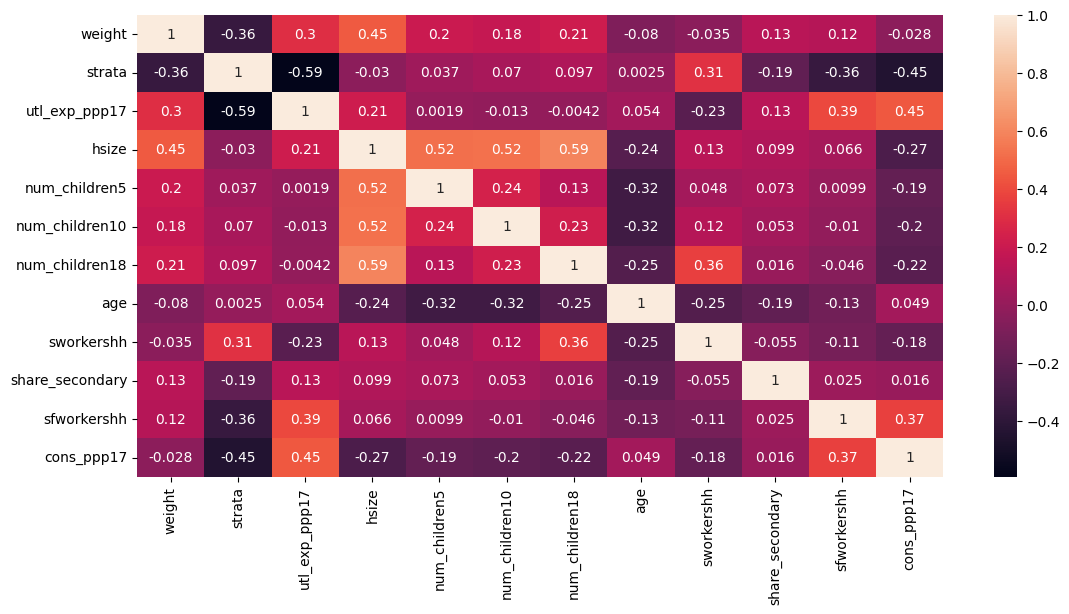

In [131]:
corr_cols = ['weight', 'strata', 'utl_exp_ppp17', 'hsize',
       'num_children5', 'num_children10', 'num_children18', 'age', 'sworkershh', 'share_secondary', 'sfworkershh', 'cons_ppp17']


plt.figure(figsize=(13,6))
sns.heatmap(xy_data[corr_cols].corr(), annot=True)
plt.show() 

## Outlier Detection

#find outlier

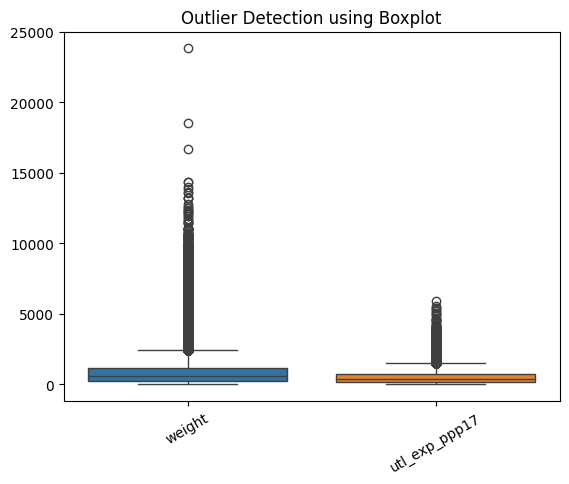

In [132]:
outlier_cols = ['weight', 'utl_exp_ppp17']

sns.boxplot(data=xy_data[outlier_cols])
plt.xticks(rotation=30)
plt.title("Outlier Detection using Boxplot")
plt.show()


#Remove outlier

In [133]:
xy_data.shape

(104234, 86)

In [134]:
# #1. Method to remove outliers using IQR
# def outlier_remover_IQR(xy_data, col):
#     q1 = xy_data[col].quantile(0.25)
#     q3 = xy_data[col].quantile(0.75)

#     IQR = q3 - q1
#     min_range = q1 - 1.5 * IQR
#     max_range = q3 + 1.5 * IQR

#     filtered_data = xy_data[(xy_data[col] <= max_range)]
#     return filtered_data

# #2. Z-score method to remove outliers
# def outlier_remover_zscore(xy_data, col):

#     min_range = xy_data[col].mean() - 3*xy_data[col].std()
#     max_range = xy_data[col].mean() + 3*xy_data[col].std()
    
#     filtered_data = xy_data[(xy_data[col] <= max_range)]
#     return filtered_data




# for col in outlier_cols:
#     xy_data = outlier_remover_IQR(xy_data, col)

## Data Visualizaion

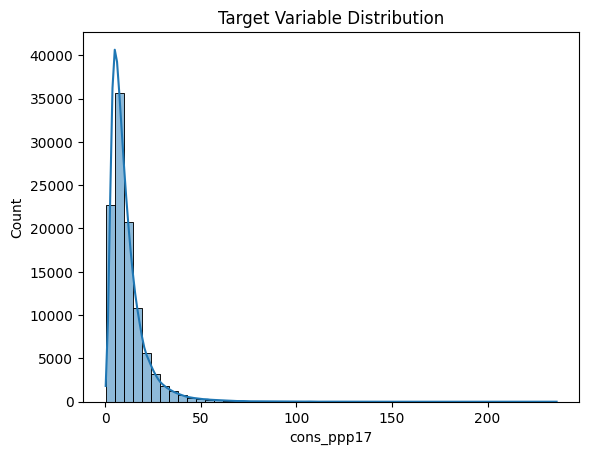

In [135]:
sns.histplot(xy_data['cons_ppp17'], bins=50, kde=True)
plt.title("Target Variable Distribution")
plt.show()

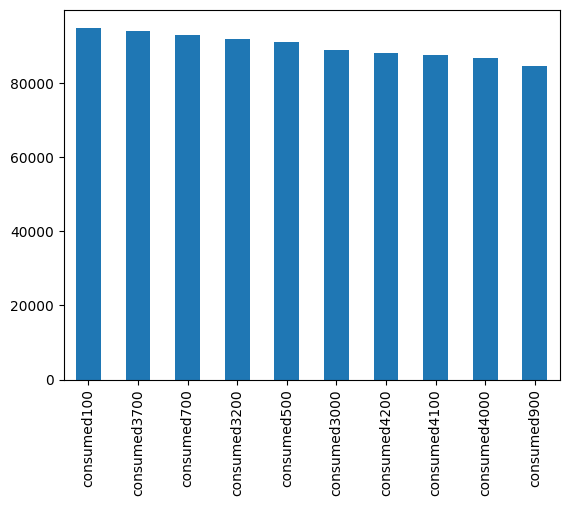

In [136]:
cons_cols = [c for c in xy_data.columns if 'consumed' in c]
xy_data[cons_cols].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.show()

In [137]:
# Data Devide X and Y
x = xy_data.drop(columns=['cons_ppp17'])
y = xy_data['cons_ppp17']

## Data Scaling

In [138]:
# #1. Method StandardScaler
# ss = StandardScaler()
# norm_data = ss.fit_transform(x)
# x = pd.DataFrame(norm_data, columns=x.columns)

In [139]:
#2. Method RobustScaler (Outlier Effected)
rob_scal = RobustScaler()
rob_data = rob_scal.fit_transform(x)
x = pd.DataFrame(rob_data, columns=x.columns)

In [140]:
# #3. Method MinMaxScaler (Deep Learning)
# min_max_s = MinMaxScaler()
# x = pd.DataFrame(min_max_s.fit_transform(x), columns=x.columns)

### Train test split data

In [141]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Cross Validation

In [ ]:
lgbm_cv_model = cross_val_score(estimator=LGBMRegressor(), X=x_train, y=y_train, cv=KFold(n_splits=10, shuffle=True, random_state=42), scoring='r2', verbose=False)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.035628 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 927
[LightGBM] [Info] Number of data points in the train set: 75048, number of used features: 85
[LightGBM] [Info] Start training from score 11.575783
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 926
[LightGBM] [Info] Number of data points in the train set: 75048, number of used features: 85
[LightGBM] [Info] Start training from score 11.556300
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022573 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enoug

In [ ]:
xgb_cv_model = cross_val_score(estimator=XGBRegressor(), X=x_train, y=y_train, cv=KFold(n_splits=10, shuffle=True, random_state=42), scoring='r2', verbose=False)

In [ ]:
cbr_cv_model = cross_val_score(estimator=CatBoostRegressor(), X=x_train, y=y_train, cv=KFold(n_splits=5, shuffle=True, random_state=42), scoring='r2', verbose=False)

Learning rate set to 0.079506
0:	learn: 9.7268981	total: 150ms	remaining: 2m 30s
1:	learn: 9.4217283	total: 164ms	remaining: 1m 21s
2:	learn: 9.1543252	total: 178ms	remaining: 59.1s
3:	learn: 8.8990942	total: 192ms	remaining: 47.9s
4:	learn: 8.6715375	total: 213ms	remaining: 42.3s
5:	learn: 8.4752052	total: 234ms	remaining: 38.8s
6:	learn: 8.3077720	total: 249ms	remaining: 35.3s
7:	learn: 8.1449077	total: 263ms	remaining: 32.6s
8:	learn: 7.9913554	total: 277ms	remaining: 30.5s
9:	learn: 7.8599761	total: 291ms	remaining: 28.8s
10:	learn: 7.7428470	total: 304ms	remaining: 27.3s
11:	learn: 7.6451031	total: 317ms	remaining: 26.1s
12:	learn: 7.5448215	total: 329ms	remaining: 25s
13:	learn: 7.4538408	total: 344ms	remaining: 24.3s
14:	learn: 7.3728029	total: 364ms	remaining: 23.9s
15:	learn: 7.2907858	total: 379ms	remaining: 23.3s
16:	learn: 7.2223673	total: 392ms	remaining: 22.7s
17:	learn: 7.1584000	total: 419ms	remaining: 22.8s
18:	learn: 7.1003670	total: 437ms	remaining: 22.6s
19:	learn: 

In [ ]:
print(f"LGBM CV Model: {sorted(lgbm_cv_model)}")
print(f"XGB CV Model: {sorted(xgb_cv_model)}")
print(f"CBR CV Model: {sorted(cbr_cv_model)}")

LGBM CV Model: [0.6191778464989747, 0.6304987700147997, 0.6317347769957269, 0.6322468474422462, 0.6408393995171717, 0.6504012578700988, 0.6517100202685866, 0.6528111833979939, 0.6565003077613736, 0.6683572978382271]
XGB CV Model: [0.6110178422350634, 0.6268839634025511, 0.6282912090439474, 0.6358409294294799, 0.6385395022909507, 0.6400519556455057, 0.6413792012282782, 0.642680342088193, 0.6447700804303613, 0.6597901346402075]
CBR CV Model: [0.6432989562784499, 0.6491857393923672, 0.6611581219919385, 0.6650783180519977, 0.666545150838397]


## Feature Selection 

In [ ]:
# fs = SequentialFeatureSelector(XGBRegressor(), n_features_to_select='auto')
# fs.fit(x_train, y_train)

## Model Building and Training

#### Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [ ]:
lr.score(x_test, y_test)*100, lr.score(x_train, y_train)*100

(50.0645156251926, 50.314407861018125)

#### Decision Tree model

In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(x_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
dt.score(x_test, y_test)*100, dt.score(x_train, y_train)*100

(19.42935455598256, 100.0)

#### Catboost model (final model)

In [ ]:
cb = CatBoostRegressor(n_estimators=1000, random_state=42, verbose=0)
cb.fit(x_train, y_train)    

In [ ]:
cb.score(x_test, y_test)*100, cb.score(x_train, y_train)*100

(67.04416027718858, 75.12411700556731)

#### LightGBM model 

In [ ]:
lgbm = LGBMRegressor(n_estimators=1000, random_state=42)
lgbm.fit(x_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033707 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 927
[LightGBM] [Info] Number of data points in the train set: 83387, number of used features: 85
[LightGBM] [Info] Start training from score 11.564958


LGBMRegressor(n_estimators=1000, random_state=42)

In [ ]:
lgbm.score(x_test, y_test)*100, lgbm.score(x_train, y_train)*100

(66.39016735403948, 85.30825927907127)

#### Xgboost model

In [ ]:
xgb = XGBRegressor(n_estimators=1000, random_state=42)
xgb.fit(x_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb.score(x_test, y_test)*100, xgb.score(x_train, y_train)*100

(61.32929595710951, 95.77940301696582)

### HyperParameter Tuning

In [ ]:
# Define parameter grid for GridSearchCV
param_grid = {
"num_leaves": [31, 63, 127],
"max_depth": [-1, 3, 5],
"subsample": [0.8, 1.0],
"colsample_bytree": [0.8, 1.0]
}

#RandomSearchCV

In [ ]:
# rscv = RandomizedSearchCV(
#     estimator=LGBMRegressor(random_state=42),
#     param_distributions=param_grid,
#     n_iter=50,  # Number of parameter settings that are sampled
#     scoring='r2',
#     cv=KFold(n_splits=5, shuffle=True, random_state=42),
#     verbose=1,
#     n_jobs=-1,
#     random_state=42
# )

# rscv.fit(x_train, y_train)

In [ ]:
# print(f'Best score: {rscv.best_score_}')
# print(f'Best parameters: {rscv.best_params_}')

# Best score: 0.6476615126594888
# Best parameters: {'subsample': 0.8, 'num_leaves': 127, 'max_depth': -1, 'colsample_bytree': 0.8}

## Evaluation and model save

In [143]:
x_final_test_copy = x_final_test.copy()


def DataPreprocessing(data):
    # Identify missing value and fill with mode
    null_cols = []
    for col in data.columns:
        if data[col].isnull().sum() > 0:
            null_cols.append(col)
    
    for col in null_cols:
        data[col].fillna(data[col].mode()[0], inplace=True)

    data.drop(columns=['hhid', 'com', 'survey_id'], inplace=True)


    # One Hot Encoding for categorical columns
    ohe_cols = [
            'male', 'owner', 'water', 'toilet', 'sewer', 'elect', 'employed', 'any_nonagric', 'urban',
            'consumed100', 'consumed200', 'consumed300', 'consumed400',
        'consumed500', 'consumed600', 'consumed700', 'consumed800',
        'consumed900', 'consumed1000', 'consumed1100', 'consumed1200',
        'consumed1300', 'consumed1400', 'consumed1500', 'consumed1600',
        'consumed1700', 'consumed1800', 'consumed1900', 'consumed2000',
        'consumed2100', 'consumed2200', 'consumed2300', 'consumed2400',
        'consumed2500', 'consumed2600', 'consumed2700', 'consumed2800',
        'consumed2900', 'consumed3000', 'consumed3100', 'consumed3200',
        'consumed3300', 'consumed3400', 'consumed3500', 'consumed3600',
        'consumed3700', 'consumed3800', 'consumed3900', 'consumed4000',
        'consumed4100', 'consumed4200', 'consumed4300', 'consumed4400',
        'consumed4500', 'consumed4600', 'consumed4700', 'consumed4800',
        'consumed4900', 'consumed5000'
    ]


    for col in ohe_cols:
        ohe = OneHotEncoder(drop='first')
        data[col] = ohe.fit_transform(data[[col]]).toarray().astype(np.int64)


    # Label Encoding for categorical columns
    label_cols = ['water_source', 'sanitation_source', 'dweltyp', 'educ_max', 'sector1d']

    for col in label_cols:
        le = LabelEncoder()
        data[col] = le.fit_transform(data[col])


    return data

x_final_test_pp = DataPreprocessing(x_final_test)

C:\Users\USER\AppData\Local\Temp\ipykernel_14228\2688662658.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mode()[0], inplace=True)


In [144]:
x_final_test_pp.shape

(103023, 85)

##

In [145]:
# # Model Save
# CatBoostModel = joblib.dump(cb, "CatboostModel.pkl")

In [146]:
# Model Load
prediction_model = joblib.load("CatboostModel.pkl")

In [147]:
#Predict
y_prd = prediction_model.predict(x_test)

In [148]:
#Evaluation
print(f"MAE Error: {mean_absolute_error(y_test, y_prd)}")
print(f"MSE Error: {mean_squared_error(y_test, y_prd)}")
print(f"R2 Error: {r2_score(y_test,y_prd)}")

MAE Error: 4.012405846169936
MSE Error: 55.13598659762372
R2 Error: 0.45122122382143137


## Final Competition Submission

#### file1: predicted_household_consumption.csv

In [149]:
final_prd = prediction_model.predict(x_final_test_pp)

In [150]:
p = x_final_test_copy[['survey_id', 'hhid']]

In [151]:
p.rename(columns={'hhid':'household_id'}, inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_14228\2347222067.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  p.rename(columns={'hhid':'household_id'}, inplace=True)


In [152]:
p.head()

,survey_id,household_id
0,400000,400001
1,400000,400002
2,400000,400003
3,400000,400004
4,400000,400005


In [153]:
final_prd = pd.DataFrame(final_prd, columns=['cons_ppp17'])
sub_file = pd.concat([p, final_prd], axis=1)

In [156]:
sub_file.head()

,survey_id,household_id,cons_ppp17
0,400000,400001,6.356292
1,400000,400002,4.972875
2,400000,400003,8.481035
3,400000,400004,9.972712
4,400000,400005,10.311446


In [157]:
sub_file.to_csv("predicted_household_consumption.csv", index=False)
print("Final submission")

Final submission


In [158]:
sub = pd.read_csv('predicted_household_consumption.csv')
sub.head()

,survey_id,household_id,cons_ppp17
0,400000,400001,6.356292
1,400000,400002,4.972875
2,400000,400003,8.481035
3,400000,400004,9.972712
4,400000,400005,10.311446


#### file2: predicted_poverty_distribution.csv

In [172]:
thresholds = [
    3.17, 3.94, 4.60, 5.26, 5.88, 6.47, 7.06, 7.70, 8.40,
    9.13, 9.87, 10.70, 11.62, 12.69, 14.03, 15.64,
    17.76, 20.99, 27.37
]

test =  sub

poverty_rows = []

for sid, df in test.groupby('survey_id'):
    row = {'survey_id': sid}

    for t in thresholds:
        rate = (df['cons_ppp17'] < t).mean()
        row[f'pct_hh_below_{t}'] = rate

    poverty_rows.append(row)

poverty_df = pd.DataFrame(poverty_rows)
poverty_df.rename(columns={'pct_hh_below_4.6':'pct_hh_below_4.60', 'pct_hh_below_7.7':'pct_hh_below_7.70', 'pct_hh_below_8.4':'pct_hh_below_8.40', 'pct_hh_below_10.7':'pct_hh_below_10.70' }, inplace=True)


In [173]:
poverty_df.to_csv("predicted_poverty_distribution.csv", index=False)
